In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/Intern')

Mounted at /content/drive


内光带上边缘 y = 225
内光带下边缘 y = 173
内光带高度 N1 = 52
[104.8332 257.0784 409.3236 466.0424]
High-amplitude segment centers (cols): [15.0, 66.5, 117.5, 136.5]
After internal fix: Bright marker at col 113, θ=397.4°
After internal fix: Dark   marker at col 53, θ=218.3°
Dark marker:   left=203.34, right=233.20, width=29.85 deg
Bright marker: left=391.41, right=427.23, width=35.82 deg
LX.txt
      method dark_dir bright_dir  opposite?
0     Simple    diag1      diag1      False
1  Segmented    diag1      diag2       True
2      Radon    diag1      diag2       True
3      Gabor    diag1      diag1      False
4      Hough    diag2      diag2      False
5  Reference    diag1      diag2       True
Final Segmented Tuned endpoints:
   marker        x0   y0        x1   y1
0    dark  203.3448  228  233.1968  170
1  bright  391.4124  170  427.2348  228
内光带上边缘 y = 225
内光带下边缘 y = 173
内光带高度 N1 = 52
[167.5224 346.6344 492.9092]
High-amplitude segment centers (cols): [36.5, 96.0, 145.5]
After internal fix: Bright 

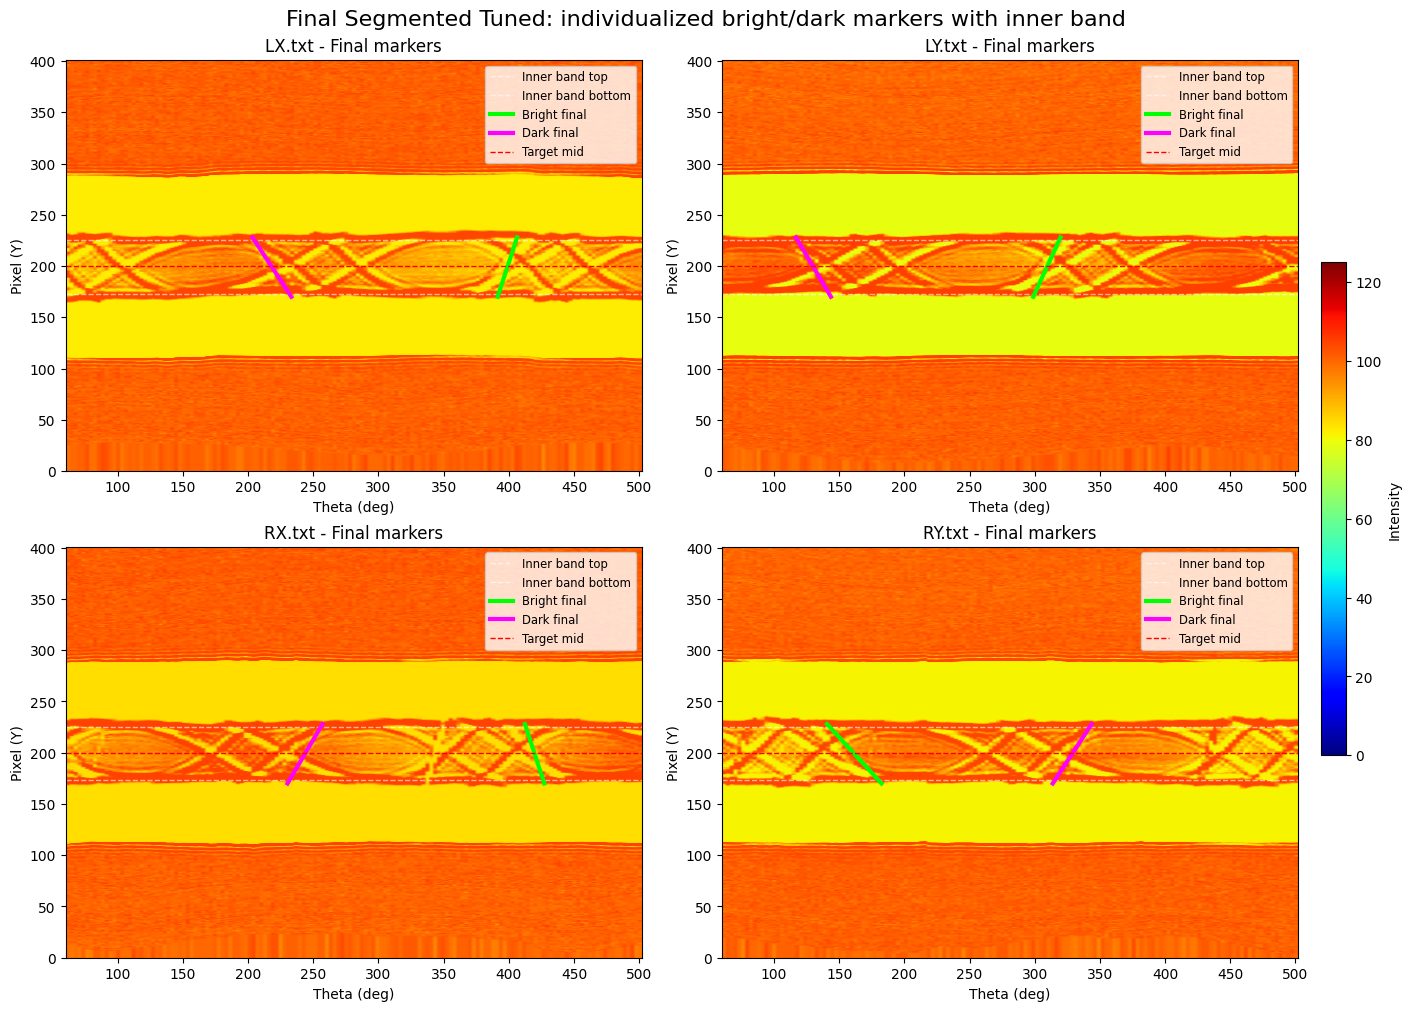


 Alignment completed

=== Saving raw data according to index ===
Already existent：index.csv
Index: 132
LX.txt: copied.
LY.txt: copied.
RX.txt: copied.
RY.txt: copied.

=== Summary table below ===
  file    method dark_dir bright_dir  opposite?  theta_sep  sep_pass?
LX.txt     Gabor    diag1      diag1      False   179.1120       True
LX.txt     Hough    diag2      diag2      False   179.1120       True
LX.txt     Radon    diag1      diag2       True   179.1120       True
LX.txt Reference    diag1      diag2       True   179.1120       True
LX.txt Segmented    diag1      diag2       True   179.1120       True
LX.txt    Simple    diag1      diag1      False   179.1120       True
LY.txt     Gabor    diag1      diag1      False   177.9028       True
LY.txt     Hough    diag2      diag2      False   177.9028       True
LY.txt     Radon    diag2      diag2      False   177.9028       True
LY.txt Reference    diag1      diag2       True   177.9028       True
LY.txt Segmented    diag1      di

KeyboardInterrupt: Interrupted by user

In [ ]:
def main():


    ###################################################
    #               Loading Packages
    ###################################################

    import numpy as np
    import pandas as pd
    import math
    import matplotlib.pyplot as plt
    from scipy.ndimage import gaussian_filter, shift, sobel, gaussian_filter1d
    from skimage.measure import LineModelND, ransac
    from scipy.signal import find_peaks
    from skimage.draw import line as draw_line
    from matplotlib import patches
    import numpy.fft as fft
    from skimage.transform import probabilistic_hough_line
    import os
    import sys
    import glob
    import tkinter as tk
    from tkinter import filedialog
    from skimage import exposure
    from scipy.ndimage import laplace
    from skimage.transform import radon
    from skimage.filters import gabor
    from skimage.feature import canny
    from scipy.ndimage import distance_transform_edt
    from skimage.feature import structure_tensor
    from skimage.feature import corner_harris
    from skimage.feature import structure_tensor_eigenvalues
    from datetime import datetime
    from scipy.ndimage import median_filter
    from scipy.interpolate import interp1d
    from scipy.ndimage import uniform_filter1d
    from scipy.ndimage import map_coordinates
    from scipy.signal import savgol_filter

    all_marker_crossings = []
    straight_images = {}
    summary_rows   = []
    # 用于后面候选替换逻辑的全局容器（必须在每张图处理前定义一次）
    markers_candidates = {}   # 保存每张图的 bright_cands / dark_cands（列索引）
    thetas_selected = {}      # 保存每张图最终选定的 bright/dark theta
    band_data = {}

 #   if getattr(sys, 'frozen', False):
  #      # exe 所在的目录
  #      base_dir = os.path.dirname(sys.executable)
 #   else:
 #       # 脚本未打包时，使用脚本文件所在目录
  #      base_dir = os.path.dirname(os.path.abspath(__file__))

    #os.chdir(base_dir)
    #print(f"当前工作目录：{base_dir}")

    ###################################################
    #                   Main Loop
    ###################################################

    for file_path in ["LX.txt", "LY.txt", "RX.txt", "RY.txt"]:

    ###################################################
    #   Loading data & Smoothing and Sharpening
    ###################################################

        # 1. 读取数据
        with open(file_path, encoding="utf-8") as f:
            lines = f.readlines()

        # 解析：跳过第2、3行
        theta = np.array([float(x) for x in lines[0].strip().split(',') if x])
        data_lines = lines[3:]
        data_matrix = np.array([[float(x) for x in l.strip().split(',') if x] for l in data_lines])
        temp_df = pd.DataFrame(lines)

        # 2. 高斯平滑 + 图像锐化
        sigma = 0
        # 先模糊
        blur = gaussian_filter(data_matrix, sigma=sigma)
        # 再对模糊结果做一次更大半径的模糊，用于提取高频细节
        blur2 = gaussian_filter(blur, sigma=sigma*2)
        # 无锐化掩模：高频细节 = blur - blur2
        mask = blur - blur2
        # 将细节按比例叠加回原图
        alpha = 1.6  # 锐化强度，可调
        data_smooth = blur + alpha * mask
        data_smooth_bf = data_smooth.copy()

    ###################################################
    #      Edge Detection & Straightening
    ###################################################

        # 计算垂直梯度（先轻度平滑再 sobel）
        Gy_tmp = gaussian_filter(data_smooth_bf, sigma=1.0)
        Gy = np.abs(sobel(Gy_tmp, axis=0)).astype(np.float32)

        H_bf, W_bf = data_smooth_bf.shape

        # 上/下搜索窗（按高度比例）
        top_window = (0.05, 0.35)
        bot_window = (0.65, 0.95)
        min_window_rows = 8  # 搜索窗最小高度，防空切片

        # ——安全窗口（上）
        yt0 = max(0, int(round(H_bf * top_window[0])))
        yt1 = max(yt0 + 1, int(round(H_bf * top_window[1])))
        if (yt1 - yt0) < min_window_rows:
            pad = (min_window_rows - (yt1 - yt0)) // 2 + 1
            yt0 = max(0, yt0 - pad)
            yt1 = min(H_bf, yt1 + pad)
        if yt0 >= H_bf: yt0 = H_bf - 1
        if yt1 <= yt0: yt1 = min(H_bf, yt0 + 1)

        # ——安全窗口（下）
        yb0 = max(0, int(round(H_bf * bot_window[0])))
        yb1 = max(yb0 + 1, int(round(H_bf * bot_window[1])))
        if (yb1 - yb0) < min_window_rows:
            pad = (min_window_rows - (yb1 - yb0)) // 2 + 1
            yb0 = max(0, yb0 - pad)
            yb1 = min(H_bf, yb1 + pad)
        if yb0 >= H_bf: yb0 = H_bf - 1
        if yb1 <= yb0: yb1 = min(H_bf, yb0 + 1)

        # 显著性阈值（分位数）
        block_t = np.abs(Gy[yt0:yt1, :])
        block_b = np.abs(Gy[yb0:yb1, :])
        prom_t = (np.nanpercentile(block_t, 80) if block_t.size else 0.0)
        prom_b = (np.nanpercentile(block_b, 80) if block_b.size else 0.0)

        # 每列找外光带的上/下边缘
        y_top = np.full(W_bf, np.nan, dtype=np.float32)
        y_bot = np.full(W_bf, np.nan, dtype=np.float32)
        for x in range(W_bf):
            gt = block_t[:, x] if block_t.size else np.array([], dtype=np.float32)
            gb = block_b[:, x] if block_b.size else np.array([], dtype=np.float32)

            if gt.size:
                pk_t, _ = find_peaks(gt, prominence=prom_t, distance=3)
                if pk_t.size:
                    y_top[x] = yt0 + pk_t[np.argmax(gt[pk_t])]
            if gb.size:
                pk_b, _ = find_peaks(gb, prominence=prom_b, distance=3)
                if pk_b.size:
                    y_bot[x] = yb0 + pk_b[np.argmax(gb[pk_b])]

        # 依据上下间距剔离群（MAD）
        gap = y_bot - y_top
        med_gap = np.nanmedian(gap)
        mad = 1.4826 * np.nanmedian(np.abs(gap - med_gap))
        if np.isfinite(mad) and mad > 0:
            bad = np.abs(gap - med_gap) > 3.0 * mad
            y_top[bad] = np.nan
            y_bot[bad] = np.nan

        # 线性插值补全 NaN（首尾外推）
        xcol = np.arange(W_bf)

        y = y_top.copy()
        m = np.isfinite(y)
        if m.sum() >= 2:
            first, last = np.flatnonzero(m)[0], np.flatnonzero(m)[-1]
            y[:first] = y[first]; y[last+1:] = y[last]
            y[~m] = np.interp(xcol[~m], xcol[m], y[m])
        elif m.sum() == 1:
            y[:] = y[m][0]
        else:
            y[:] = H_bf * 0.25
        y_top = y

        y = y_bot.copy()
        m = np.isfinite(y)
        if m.sum() >= 2:
            first, last = np.flatnonzero(m)[0], np.flatnonzero(m)[-1]
            y[:first] = y[first]; y[last+1:] = y[last]
            y[~m] = np.interp(xcol[~m], xcol[m], y[m])
        elif m.sum() == 1:
            y[:] = y[m][0]
        else:
            y[:] = H_bf * 0.75
        y_bot = y

        # 沿列方向平滑（高斯1D，避免另加依赖）
        sigma_cols = max(1.0, 0.01 * W_bf)
        y_top_s = gaussian_filter1d(y_top, sigma=sigma_cols, mode='nearest')
        y_bot_s = gaussian_filter1d(y_bot, sigma=sigma_cols, mode='nearest')

        # 中线 = (上 + 下)/2
        y_mid = 0.5 * (y_top_s + y_bot_s)

        # 计算位移：把中线对齐到 y 轴范围的中心值
        target_mid_bf = (H_bf - 1) / 2.0    # 或者用 H_bf / 2.0
        shifts_bf = target_mid_bf - y_mid

        # 补齐 NaN 位移
        if not np.isfinite(shifts_bf).all():
            mm = np.isfinite(shifts_bf)
            shifts_bf[~mm] = (float(np.nanmedian(shifts_bf[mm])) if mm.any() else 0.0)

        # 拉直图像：每列按浮点 shift 平移
        straight_img_bf = np.zeros_like(data_smooth_bf)
        for i in range(W_bf):
            straight_img_bf[:, i] = shift(
                data_smooth_bf[:, i],
                shift=float(shifts_bf[i]),
                order=1,
                mode='nearest'
            )

        # 可视化对齐效果
        #plt.figure(figsize=(10,4))
        #plt.plot(mid_line_bf, label='Original mid_line', alpha=0.3)
        #plt.plot(mid_line_smoothed_bf, label='Smoothed mid_line', lw=2)
        #plt.axhline(y=target_mid_bf, color='red', linestyle='--', label='Target center')
        #plt.title(f"{file_path} - Midline filtering and alignment (BF)")
        #plt.xlabel("Column index")
        #plt.ylabel("Y (row)")
        #plt.legend()
        #plt.tight_layout()
        #plt.show()

    ###################################################
    #             Detecting Inner Band
    ###################################################

        mid_y_bf = straight_img_bf.shape[0] // 2
        search_width_bf = 30

        # 1. 计算梯度
        grad_bf = np.abs(sobel(straight_img_bf, axis=0))

        # 2. 检测原始上下边缘
        edge_top_i_bf = np.zeros(straight_img_bf.shape[1], dtype=int)
        edge_bottom_i_bf = np.zeros(straight_img_bf.shape[1], dtype=int)
        for i in range(straight_img_bf.shape[1]):
            col_grad_bf = grad_bf[:, i]
            edge_top_i_bf[i]    = np.argmax(col_grad_bf[mid_y_bf:mid_y_bf+search_width_bf]) + mid_y_bf
            edge_bottom_i_bf[i] = np.argmax(col_grad_bf[mid_y_bf-search_width_bf:mid_y_bf]) + (mid_y_bf-search_width_bf)

        # 3. 调整inner band上下边缘
        min_t_i_bf = np.mean(edge_top_i_bf)
        for i in range(len(edge_top_i_bf)):
            edge_top_i_bf[i] = min_t_i_bf
        max_b_i_bf = np.mean(edge_bottom_i_bf)
        for i in range(len(edge_bottom_i_bf)):
            edge_bottom_i_bf[i] = max_b_i_bf

        # 5. 输出内光带的值
        center_idx_bf = straight_img_bf.shape[1] // 2
        print(f"内光带上边缘 y = {edge_top_i_bf[center_idx_bf]}")
        print(f"内光带下边缘 y = {edge_bottom_i_bf[center_idx_bf]}")
        N1_bf = edge_top_i_bf[center_idx_bf] - edge_bottom_i_bf[center_idx_bf]
        print(f"内光带高度 N1 = {N1_bf}")

    ###################################################
    #       Clamp Pixel Intensities
    ###################################################
        # 设置要保留的分位范围（比如去掉最顶端 0.5% 的极端亮）
        p_low = 30
        p_high = 90

        low = np.percentile(straight_img_bf, p_low)
        high = np.percentile(straight_img_bf, p_high)

        # 可选：再扩一点 margin（比如加 5%）
        margin_c = 0.05 * (high - low)
        min_intensity = max(0, low - margin_c)
        max_intensity = high + margin_c

        straight_img_bf = np.clip(straight_img_bf, min_intensity, max_intensity)

    ###################################################
    #       Finding Approximated Markers (Amplitude)
    ###################################################

        # 1. 计算每列内光带的亮度振幅（峰峰值）
        amplitude_bf = np.zeros(W_bf, dtype=float)
        for j in range(W_bf):
            y0 = int(edge_bottom_i_bf[j] + 15)
            y1 = int(edge_top_i_bf[j] - 15)
            # 边界夹紧
            y0 = max(0, min(H_bf - 1, y0))
            y1 = max(0, min(H_bf - 1, y1))
            if y1 <= y0:
                amplitude_bf[j] = 0.0
            else:
                prof = straight_img_bf[y0:y1+1, j]
                if prof.size:
                    amplitude_bf[j] = float(np.nanmax(prof) - np.nanmin(prof))
                else:
                    amplitude_bf[j] = 0.0

        # 2. 平滑振幅曲线
        amplitude_bf = gaussian_filter1d(amplitude_bf, sigma=5)

        # 3. 可视化振幅 vs 角度
        """
        plt.figure(figsize=(10,4))
        plt.plot(theta, amplitude_bf, '-', lw=1)
        plt.xlabel("Theta (deg)")
        plt.ylabel("Brightness amplitude")
        plt.title("Inner–band brightness amplitude per angle")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        """

        # 4. 阈值筛选高振幅列
        amp_thresh_bf = 1.2 * np.mean(amplitude_bf)

        # 5. 生成新的图像副本并标记高振幅列
        cleaned_bf = straight_img_bf.copy()
        high_cols_bf = np.where(amplitude_bf > amp_thresh_bf)[0]
        pad_bf = 0
        mask_cols_bf = np.zeros(W_bf, dtype=bool)
        for j in high_cols_bf:
            j0 = max(0, j - pad_bf)
            j1 = min(W_bf - 1, j + pad_bf)
            mask_cols_bf[j0:j1+1] = True

        # 6. 计算内光带总平均亮度
        vals = []
        for j in range(W_bf):
            y0 = int(edge_bottom_i_bf[j])
            y1 = int(edge_top_i_bf[j])
            y0 = max(0, min(H_bf - 1, y0))
            y1 = max(0, min(H_bf - 1, y1))
            if y1 > y0:
                band = straight_img_bf[y0:y1+1, j]
                if band.size:
                    vals.append(float(np.nanmean(band)))
        mean_intensity_bf = float(np.nanmean(vals)) if len(vals) else float(np.nanmean(straight_img_bf))


        # 7. 只替换内光带中极端高/低亮度像素为平均亮度
        # 方法 B（替代 A）：基于百分位数，比如替换最顶部和最底部 5%
        pct = 0
        for j in np.where(mask_cols_bf)[0]:
            y0 = int(edge_bottom_i_bf[j])
            y1 = int(edge_top_i_bf[j])
            band = straight_img_bf[y0:y1+1, j]
            low_thresh = np.percentile(band, pct)
            high_thresh = np.percentile(band, 100 - pct)
            extreme_mask = (band < low_thresh) | (band > high_thresh)
            band_corrected = band.copy()
            band_corrected[extreme_mask] = mean_intensity_bf - 5
            cleaned_bf[y0:y1+1, j] = band_corrected

        straight_img_bf = cleaned_bf.copy()

        mid_y_bf = straight_img_bf.shape[0] // 2
        N_bf    = 5

        # 保存用于 reliability 计算的 data
        band_data[file_path] = {
            'img': straight_img_bf,           # 用于取内光带 profile
            'edge_top': edge_top_i_bf,        # 上边界
            'edge_bottom': edge_bottom_i_bf,  # 下边界
        }

        # 9. 基于内光带中心区域重新定位 marker
        region_bf = straight_img_bf[mid_y_bf - N_bf:mid_y_bf + N_bf + 1, :]
        profile_sum_bf = region_bf.sum(axis=0)

        margin = 10
        all_cols_bf = np.arange(W_bf)


        def shrink_mask(mask, shrink=1):
            """把每个连续 True 段两端各收 shrink 个，使排除区域变窄。"""
            result = np.zeros_like(mask, dtype=bool)
            N = len(mask)
            i = 0
            while i < N:
                if not mask[i]:
                    i += 1
                    continue
                j = i
                while j+1 < N and mask[j+1]:
                    j += 1
                # 现在 segment 是 [i, j]
                new_i = i + shrink
                new_j = j - shrink
                if new_i <= new_j:
                    result[new_i:new_j+1] = True
                i = j + 1
            return result

        def find_segment_centers(mask):
            """给定 bool 一维 mask，返回每个连续 True 段的中心索引（float）。"""
            centers = []
            N = len(mask)
            i = 0
            while i < N:
                if not mask[i]:
                    i += 1
                    continue
                j = i
                while j+1 < N and mask[j+1]:
                    j += 1
                # segment is [i, j]
                centers.append((i + j) / 2.0)
                i = j + 1
            return centers

        # —— 先找高振幅段的中心 —— #
        high_amp_centers = find_segment_centers(mask_cols_bf)  # e.g. [23.5, 78.0, ...]
        idxtt = np.asarray(high_amp_centers, dtype=int)  # 转成整数索引
        idxtt = idxtt[(idxtt >= 0) & (idxtt < theta.size)]     # 可选：防越界
        print(theta[idxtt])

        # 打印/保存这些中心（x 坐标，可以是非整数）
        print("High-amplitude segment centers (cols):", high_amp_centers)

        # 构造一个新的排除 mask：排除每个 center 及其左右扩展 width
        exclude_width = 0  # 避开中心左右几列，可调成 1,2,...
        expanded_exclude = np.zeros(W_bf, dtype=bool)
        for c in high_amp_centers:
            c_round = int(round(c))
            lo = max(0, c_round - exclude_width)
            hi = min(W_bf - 1, c_round + exclude_width)
            expanded_exclude[lo:hi+1] = True

        # 最终 valid columns：去掉 margin 和扩展的高振幅中心邻近列
        valid_cols_bf = all_cols_bf[
            (all_cols_bf >= margin)
            & (all_cols_bf < W_bf - margin)
            & (~expanded_exclude)          # 避免高振幅中心及邻近
        ]

        # === top-K 候选（bright: 最小, dark: 最大） ===
        def angle_diff(a, b):
            return abs((a - b + 180) % 360 - 180)

        def adjust_theta_sum(a, b):
            s = (a + b) % 360
            return s if abs(s) > 5 else s + 360

        def top_k_candidates_on_valid(profile, valid_indices, kind='bright', K=10):
            if kind == 'bright':
                order = np.argsort(profile[valid_indices])  # 越小越好
            else:
                order = np.argsort(-profile[valid_indices])  # 越大越好
            chosen = valid_indices[order][:K]
            return list(chosen)

        # 用 valid_cols_bf 生成候选
        bright_cands = top_k_candidates_on_valid(profile_sum_bf, valid_cols_bf, kind='bright', K=10)
        dark_cands  = top_k_candidates_on_valid(profile_sum_bf, valid_cols_bf, kind='dark',  K=10)

        # 先选第一对做 internal 180° 检查
        selected = {'bright_idx': bright_cands[0], 'dark_idx': dark_cands[0]}
        bright_theta = theta[selected['bright_idx']]
        dark_theta  = theta[selected['dark_idx']]

        # internal (bright vs dark) 应接近 180°
        tol_internal = 15
        if abs(angle_diff(bright_theta, dark_theta) - 180) > tol_internal:
            fixed = False
            # 固定 bright 尝试替换 dark
            for di in dark_cands[1:]:
                cand_dark = theta[di]
                if abs(angle_diff(bright_theta, cand_dark) - 180) <= tol_internal:
                    selected['dark_idx'] = di
                    dark_theta = cand_dark
                    fixed = True
                    print(f"[{file_path}] replaced dark with candidate {di} to satisfy internal 180°.")
                    break
            # 固定 dark 尝试替换 bright
            if not fixed:
                for bi in bright_cands[1:]:
                    cand_bright = theta[bi]
                    if abs(angle_diff(cand_bright, dark_theta) - 180) <= tol_internal:
                        selected['bright_idx'] = bi
                        bright_theta = cand_bright
                        fixed = True
                        print(f"[{file_path}] replaced bright with candidate {bi} to satisfy internal 180°.")
                        break
            if not fixed:
                print(f"Alarm: [{file_path}] cannot satisfy internal 180° with any candidate pair. Keeping initial pair.")

        # 最终确定的 bright/dark
        bright_idx = selected['bright_idx']
        dark_idx  = selected['dark_idx']
        bright_theta = theta[bright_idx]
        dark_theta  = theta[dark_idx]

        print(f"After internal fix: Bright marker at col {bright_idx}, θ={bright_theta:.1f}°")
        print(f"After internal fix: Dark   marker at col {dark_idx}, θ={dark_theta:.1f}°")

        # 保存 candidates 和选中的 theta 供后续 pairwise 修复用
        markers_candidates[file_path] = {'bright_cands': bright_cands, 'dark_cands': dark_cands}
        thetas_selected[file_path] = {'bright': bright_theta, 'dark': dark_theta}

    ###################################################
    #     Calculating Cummulative Gray Intensity
    ###################################################

        cum_intensity = np.zeros_like(theta)
        for i in range(straight_img_bf.shape[1]):
            y2 = edge_top_i_bf[i] - 5
            y1 = edge_bottom_i_bf[i] + 5
            y2 = min(max(y2, 0), straight_img_bf.shape[0]-1)
            y1 = min(max(y1, 0), straight_img_bf.shape[0]-1)
            if y2 >= y1:
                cum_intensity[i] = straight_img_bf[y1:y2+1, i].sum()
            else:
                cum_intensity[i] = 0

        # 高斯平滑（sigma 可调，常用 2~5）
        cum_intensity_smooth = gaussian_filter1d(cum_intensity, sigma=0.2)

        if file_path not in band_data:
            band_data[file_path] = {}
        band_data[file_path]['profile_smooth'] = cum_intensity_smooth.copy()

    ###################################################
    #              Finding Marker Ranges
    ###################################################

        window = 3

        # —— 精确定位 marker ——
        # dark marker：检测谷值
        search_d = slice(max(0, dark_idx-window), min(len(theta), dark_idx+window+1))
        local_valleys, _ = find_peaks(-cum_intensity_smooth[search_d])
        if len(local_valleys) > 0:
            true_dark_idx = local_valleys[np.argmin(cum_intensity_smooth[search_d][local_valleys])] + search_d.start
        else:
            true_dark_idx = dark_idx

        # bright marker：检测峰值
        search_b = slice(max(0, bright_idx-window), min(len(theta), bright_idx+window+1))
        local_peaks, _ = find_peaks(cum_intensity_smooth[search_b])
        if len(local_peaks) > 0:
            true_bright_idx = local_peaks[np.argmax(cum_intensity_smooth[search_b][local_peaks])] + search_b.start
        else:
            true_bright_idx = bright_idx


        def find_nearest_valid_boundary(arr, center_idx, mode='valley',
                                        max_search=30, min_prominence=0.1):
            """
            更敏感的峰/谷检测：
              - mode='valley' 时在 -arr 上找峰
              - mode='peak'  时在 arr 上找峰
            然后分别选出中心点左右最近的那个极值位置，并在此基础上扩展 ±1。
            """
            N = len(arr)
            lo = max(0, center_idx - max_search)
            hi = min(N, center_idx + max_search + 1)
            seg = arr[lo:hi]

            if mode == 'valley':
                # 在 -seg 上找峰，也就是 arr 的谷
                peaks, props = find_peaks(-seg, prominence=min_prominence)
            else:
                peaks, props = find_peaks(seg, prominence=min_prominence)

            if len(peaks) == 0:
                # 找不到就退回到 center_idx ±1
                return max(0, center_idx-1), min(N-1, center_idx+1)

            # 转成全局索引
            peaks = peaks + lo
            # 左侧候选：< center_idx
            left_cand = peaks[peaks < center_idx]
            # 右侧候选：> center_idx
            right_cand = peaks[peaks > center_idx]

            # 分别选最近的
            left = int(left_cand[-1])   if len(left_cand)  else center_idx
            right= int(right_cand[0])   if len(right_cand) else center_idx

            # 最小扩展：±1
            return max(0, left-1), min(N-1, right+1)

        # 使用方法：
        # dark marker (valley)
        dark_left, dark_right = find_nearest_valid_boundary(cum_intensity_smooth, true_dark_idx, mode='valley', max_search=40)
        # bright marker (peak)
        bright_left, bright_right = find_nearest_valid_boundary(cum_intensity_smooth, true_bright_idx, mode='peak', max_search=40)

        print(f"Dark marker:   left={theta[dark_left]:.2f}, right={theta[dark_right]:.2f}, width={theta[dark_right] - theta[dark_left]:.2f} deg")
        print(f"Bright marker: left={theta[bright_left]:.2f}, right={theta[bright_right]:.2f}, width={theta[bright_right] - theta[bright_left]:.2f} deg")

        mid_y = straight_img_bf.shape[0] // 2

    ###################################################
    #        Regulating and Fitting Markers
    ###################################################

        # —— 参数 —— #
        mgn = 3     # 垂直收缩 margin
        sgm = 15    # 采样点数
        w_mean = 0.7
        w_fluc = 0.3

        # —— 函数定义 —— #

        def pick_diag_dir_simple(
            left: int,
            right: int,
            edge_top: np.ndarray,
            edge_bottom: np.ndarray,
            img: np.ndarray,
            marker_type: str,
            ver_margin: int = mgn,
            neighbor: int = 2,
            w_mean: float = w_mean,
            w_fluc: float = w_fluc,
            min_prom: float = 0.05      # 峰/谷显著度阈值
        ) -> str:
            h, w = img.shape
            y_top_min = int(edge_top[left:right+1].min()) + ver_margin
            y_bot_max = int(edge_bottom[left:right+1].max()) - ver_margin

            stats = {}
            for diag in ('diag1','diag2'):
                if diag == 'diag1':
                    (x0, y0), (x1, y1) = (left, y_top_min), (right, y_bot_max)
                else:
                    (x0, y0), (x1, y1) = (left, y_bot_max), (right, y_top_min)

                rr, cc = draw_line(y0, x0, y1, x1)
                coords = list(zip(rr, cc))
                all_vals = []
                for (r,c) in coords:
                    for dr in range(-neighbor, neighbor+1):
                        for dc in range(-neighbor, neighbor+1):
                            rr2, cc2 = r+dr, c+dc
                            if 0 <= rr2 < h and 0 <= cc2 < w:
                                all_vals.append(img[rr2, cc2])
                vals = np.array(all_vals)

                mean_intensity = vals.mean()
                # 只数显著峰/谷的次数（频率）
                n_peaks,   _ = find_peaks(vals,   prominence=min_prom)
                n_valleys, _ = find_peaks(-vals,  prominence=min_prom)
                fluctuation = len(n_peaks) + len(n_valleys)

                stats[diag] = (mean_intensity, fluctuation)

            diags = ['diag1','diag2']
            means = np.array([stats[d][0] for d in diags])
            flucs = np.array([stats[d][1] for d in diags])

            if marker_type == 'dark':
                rank_mean = np.argsort(means)
            else:
                rank_mean = np.argsort(-means)
            rank_fluc = np.argsort(flucs)

            scores = np.zeros(2)
            for i in range(2):
                im  = np.where(rank_mean == i)[0][0]
                ifl = np.where(rank_fluc  == i)[0][0]
                scores[i] = w_mean * im + w_fluc * ifl

            return diags[int(np.argmin(scores))]

        def compute_diag_stats(
            left, right, top_arr, bot_arr, img,
            ver_margin=mgn, segments=sgm
        ):
            """
            分段灰度+波动统计，返回 {'diag1':(mean,fluc),'diag2':...}
            """
            y0_full = int(top_arr[left:right+1].min())
            y1_full = int(bot_arr[left:right+1].max())
            y0 = y0_full + ver_margin
            y1 = y1_full - ver_margin

            stats = {}
            for diag in ('diag1','diag2'):
                if diag=='diag1':
                    x0,y0s,x1,y1s = left,y0,right,y1
                else:
                    x0,y0s,x1,y1s = left,y1,right,y0

                xs = np.linspace(x0,x1,segments).astype(int)
                ys = np.linspace(y0s,y1s,segments).astype(int)
                vals = img[ys, xs]

                m = vals.mean()
                pk,_ = find_peaks(vals)
                vl,_ = find_peaks(-vals)
                f = len(pk)+len(vl)
                stats[diag] = (m, f)
            return stats

        def decide(stats, marker_type, w_mean=w_mean, w_fluc=w_fluc):
            """
            加权排名决策：返回 'diag1' 或 'diag2'
            """
            diags = ['diag1','diag2']
            means = np.array([stats[d][0] for d in diags])
            flucs = np.array([stats[d][1] for d in diags])

            if marker_type=='dark':
                rm = np.argsort(means)
            else:
                rm = np.argsort(-means)
            rf = np.argsort(flucs)

            scores = np.zeros(2)
            for i in range(2):
                im = np.where(rm==i)[0][0]
                ifl = np.where(rf==i)[0][0]
                scores[i] = w_mean * im + w_fluc * ifl
            return diags[int(np.argmin(scores))]

        def get_diag_endpoints(
            left, right, top_arr, bot_arr, diag, ver_margin=mgn
        ):
            """
            根据最终方向 diag 返回两端 (x,y) 像素索引
            """
            y0_full = int(top_arr[left:right+1].min())
            y1_full = int(bot_arr[left:right+1].max())
            y0 = y0_full + ver_margin
            y1 = y1_full - ver_margin
            if diag=='diag1':
                return (left, y0), (right, y1)
            else:
                return (left, y1), (right, y0)

        # Method 1: Radon-transform peak detection
        def diag_radon(band):
            sinogram = radon(band, theta=[45,135], circle=False)
            strength_45  = sinogram[:,0].sum()
            strength_135 = sinogram[:,1].sum()
            return 'diag1' if strength_45 > strength_135 else 'diag2'

        # Method 2: Gabor-filter response
        def diag_gabor(band, freq=0.1):
            real45, _  = gabor(band, frequency=freq, theta=np.deg2rad(45))
            real135, _ = gabor(band, frequency=freq, theta=np.deg2rad(135))
            energy45  = np.abs(real45).sum()
            energy135 = np.abs(real135).sum()
            return 'diag1' if energy45 > energy135 else 'diag2'

        # Method 3: Hough-line voting
        def diag_hough(band, sigma=1):
            edges = canny(band, sigma=sigma)
            lines = probabilistic_hough_line(edges, threshold=10)
            lines45 = lines135 = 0
            for (y0,x0),(y1,x1) in lines:
                slope = (y1-y0)/(x1-x0+1e-6)
                if abs(slope-1)<0.2: lines45 +=1
                elif abs(slope+1)<0.2: lines135 +=1
            return 'diag1' if lines45 > lines135 else 'diag2'

        # 1. 简单对角线
        dark_choice   = pick_diag_dir_simple(dark_left,  dark_right,
                                            edge_top_i_bf, edge_bottom_i_bf,
                                            straight_img_bf, 'dark',
                                            ver_margin=mgn, neighbor=2)
        bright_choice = pick_diag_dir_simple(bright_left, bright_right,
                                            edge_top_i_bf, edge_bottom_i_bf,
                                            straight_img_bf, 'bright',
                                            ver_margin=mgn, neighbor=2)
        bf_ok = (dark_choice != bright_choice)

        # 4. Segmented Tuned
        stats_bf = compute_diag_stats(
            dark_left, dark_right,
            edge_top_i_bf, edge_bottom_i_bf,
            straight_img_bf,
            ver_margin=mgn, segments=sgm
        )
        segbf_d = decide(stats_bf, 'dark')
        segbf_b = decide(stats_bf, 'bright')
        segbf_ok = (segbf_d != segbf_b)

        # —— 新增的额外方法调用 ——
        region_dark = straight_img_bf[edge_bottom_i_bf.min():edge_top_i_bf.max(), dark_left:dark_right+1]
        region_bright = straight_img_bf[edge_bottom_i_bf.min():edge_top_i_bf.max(), bright_left:bright_right+1]

        dark_radon = diag_radon(region_dark)
        bright_radon = diag_radon(region_bright)

        dark_gabor = diag_gabor(region_dark)
        bright_gabor = diag_gabor(region_bright)

        dark_hough = diag_hough(region_dark)
        bright_hough = diag_hough(region_bright)

        # Reference
        if file_path == 'LX.txt' or file_path == 'LY.txt':
            dark_ref = 'diag1'
            bright_ref = 'diag2'
            print(file_path)
        else:
            dark_ref = 'diag2'
            bright_ref = 'diag1'
            print(file_path)

        seg_d_r = dark_ref
        seg_b_r = bright_ref

        # 5. 汇总 DataFrame
        df = pd.DataFrame({
            'method': [
                'Simple',
                'Segmented',
                'Radon',
                'Gabor',
                'Hough',
                'Reference',
            ],
            'dark_dir': [
                dark_choice, segbf_d,
                dark_radon, dark_gabor, dark_hough,
                dark_ref
            ],
            'bright_dir': [
                bright_choice, segbf_b,
                bright_radon, bright_gabor, bright_hough,
                bright_ref
            ],
            'opposite?': [
                bf_ok, segbf_ok,
                dark_radon!=bright_radon,
                dark_gabor!=bright_gabor,
                dark_hough!=bright_hough,
                dark_ref!=bright_ref,
            ]
        })
        print(df)

        # 6. 保存 Final Segmented Tuned 对角线端点
        dark_p0, dark_p1     = get_diag_endpoints(
            dark_left, dark_right, edge_top_i_bf, edge_bottom_i_bf, seg_d_r
        )
        bright_p0, bright_p1 = get_diag_endpoints(
            bright_left, bright_right, edge_top_i_bf, edge_bottom_i_bf, seg_b_r
        )

        df_final = pd.DataFrame([
            {'marker':'dark',   'x0':theta[dark_p0[0]],'y0':dark_p0[1],'x1':theta[dark_p1[0]],'y1':dark_p1[1]},
            {'marker':'bright', 'x0':theta[bright_p0[0]],'y0':bright_p0[1],'x1':theta[bright_p1[0]],'y1':bright_p1[1]}
        ])
        print("Final Segmented Tuned endpoints:")
        print(df_final)

        # —— 把它们 append 到 all_marker_crossings —— #
        for _, row in df_final.iterrows():
            all_marker_crossings.append({
                'file': file_path,
                'marker':   row['marker'],
                'x0':       row['x0'],
                'y0':       row['y0'],
                'x1':       row['x1'],
                'y1':       row['y1'],
            })

        # —— 收集 straight_img —— #
        straight_images[file_path] = straight_img_bf.copy()

        # —— 收集本文件各 method 的汇总行 —— #
        # 先算一下这个文件 dark/bright marker 的 theta 分离角 sep
        dark_theta   = theta[dark_idx]
        bright_theta = theta[bright_idx]
        sep = abs(bright_theta - dark_theta)
        if sep > 180: sep = 360 - sep
        sep_pass = abs(sep - 180) < 20

        # 将 df（各 method）扁平化成多行
        for _, r in df.iterrows():
            summary_rows.append({
                'file':        file_path,
                'method':      r['method'],
                'dark_dir':    r['dark_dir'],
                'bright_dir':  r['bright_dir'],
                'opposite?':   r['opposite?'],
                'theta_sep':   sep,
                'sep_pass?':   sep_pass
            })

    ###################################################
    #               End of Main Loop
    ###################################################

    ###################################################
    #        计算旋转对齐角度（Loop 结束后）
    ###################################################

    print("\n=== ALIGNMENT CALCULATION RESULTS BELOW")
    print("=======================================\n")

    # === End of main loop: rigorous internal+pairwise selection, alignment, summary, and conditional file copy ===

    # === Replacement: rigorous per-group selection (LX/LY & RX/RY), alignment, save, and summary ===
    def compute_local_snr(img, p0, p1, win=5, bg_offset=3):
        """
        在 p0→p1 对角线中点附近计算 SNR:
        - img: 2D array
        - p0,p1: (x_idx, y_pixel) 端点
        - win: 信号窗口半径
        - bg_offset: 背景窗口偏移
        """
        # 中点坐标
        xc, yc = (p0[0]+p1[0])//2, (p0[1]+p1[1])//2
        H, W = img.shape

        # 信号窗口
        xs = slice(max(0, xc-win), min(W, xc+win+1))
        ys = slice(max(0, yc-win), min(H, yc+win+1))
        sig = img[ys, xs].ravel()
        mu_sig = sig.mean()

        # 背景窗口：上下各一个偏移
        up   = img[max(0, yc-win-bg_offset): max(0, yc+win-bg_offset+1), xs].ravel()
        dn   = img[min(H, yc-win+bg_offset): min(H, yc+win+bg_offset+1), xs].ravel()
        bg   = np.concatenate([up, dn]) if (up.size+dn.size)>0 else sig
        mu_bg    = bg.mean()
        sigma_bg = bg.std(ddof=1) if bg.size>1 else 1.0

        return abs(mu_sig - mu_bg) / (sigma_bg + 1e-6)

    def compute_grad_energy(img, p0, p1):
        """
        计算 p0→p1 对角线上 Sobel 梯度能量：
        """
        # 先算全图 x/y Sobel
        gy = np.abs(sobel(img, axis=0))
        gx = np.abs(sobel(img, axis=1))
        grad = gy + gx

        # 对角线像素坐标
        rr, cc = draw_line(p0[1], p0[0], p1[1], p1[0])
        rr = np.clip(rr, 0, img.shape[0]-1)
        cc = np.clip(cc, 0, img.shape[1]-1)
        return grad[rr, cc].sum()

    def marker_endpoint_consistency(img, p0, p1, center_x, edge_top, edge_bottom, offset_range=(3, 5)):
        """
        p0, p1: marker斜线两端(x, y)
        center_x: marker斜线在中心的x位置
        offset_range: (min_offset, max_offset)，例如(3,5)
        """
        import numpy as np
        # 对角线方向单位向量
        vec = np.array([p1[0] - p0[0], p1[1] - p0[1]])
        norm = np.linalg.norm(vec)
        if norm == 0:
            return 0.0
        unit_vec = vec / norm

        # p0->中间方向offset取样
        vals0 = []
        for d in range(offset_range[0], offset_range[1]+1):
            x = int(round(p0[0] + unit_vec[0]*d))
            y = int(round(p0[1] + unit_vec[1]*d))
            if 0 <= x < img.shape[1] and 0 <= y < img.shape[0]:
                vals0.append(img[y, x])
        mean0 = np.mean(vals0) if vals0 else img[p0[1], p0[0]]

        # p1->中间方向offset取样
        vals1 = []
        for d in range(offset_range[0], offset_range[1]+1):
            x = int(round(p1[0] - unit_vec[0]*d))
            y = int(round(p1[1] - unit_vec[1]*d))
            if 0 <= x < img.shape[1] and 0 <= y < img.shape[0]:
                vals1.append(img[y, x])
        mean1 = np.mean(vals1) if vals1 else img[p1[1], p1[0]]

        # 中线亮度
        center_y = int((edge_top[center_x] + edge_bottom[center_x]) // 2)
        val_center = img[center_y, center_x]

        diff0 = abs(mean0 - val_center)
        diff1 = abs(mean1 - val_center)
        band_vals = img[edge_bottom[center_x]:edge_top[center_x]+1, center_x]
        std_band = np.std(band_vals) + 1e-3
        score0 = max(0, 1 - diff0/(2*std_band+1e-3))
        score1 = max(0, 1 - diff1/(2*std_band+1e-3))
        return 0.5*(score0 + score1)

    def angle_diff(a, b):
        return abs((a - b + 180) % 360 - 180)

    def adjust_theta_sum(a, b):
        s = (a + b) % 360
        return s if abs(s) > 5 else s + 360

    def marker_reliability(file_path, idx, band_data):
        """
        基于 SNR 和 梯度能量的可靠度评分：
        返回 0.0–1.0 之间的综合得分（bright 权重稍高于 dark）。
        """
        data = band_data.get(file_path)
        if data is None:
            return 0.0
        img = data['img']
        edge_top = data['edge_top']
        edge_bottom = data['edge_bottom']
        H, W = img.shape
        if idx < 0 or idx >= W:
            return 0.0
        # 端点
        y0 = int(edge_bottom[idx])
        y1 = int(edge_top[idx])
        if y1 <= y0:
            return 0.0
        p0 = (idx, y0)
        p1 = (idx, y1)
        # 计算 SNR 和 梯度能量
        snr_score  = compute_local_snr(img, p0, p1, win=5, bg_offset=3)
        grad_score = compute_grad_energy(img, p0, p1)
        # 归一化融合
        snr_norm  = snr_score  / (snr_score  + 1e-6)
        grad_norm = grad_score / (grad_score + 1000.0)
        # 这里是方法权重，保持不变
        # 端点一致性分数
        endpoint_consistency = marker_endpoint_consistency(img, p0, p1, idx, edge_top, edge_bottom)
        # 归一化融合：SNR:梯度:一致性 = 0.5:0.3:0.2 可调整
        w_snr_method, w_grad_method, w_consistency = 0.15, 0.15, 0.7
        return (w_snr_method * snr_norm + w_grad_method * grad_norm + w_consistency * endpoint_consistency)

    def build_internal_pairs(fname, theta, band_data, tol_internal=15):
        bright_cands = markers_candidates.get(fname, {}).get('bright_cands', [])
        dark_cands  = markers_candidates.get(fname, {}).get('dark_cands', [])
        pairs = []
        for b in bright_cands:
            for d in dark_cands:
                tb = theta[b] % 360
                td = theta[d] % 360
                if abs(angle_diff(tb, td) - 180) <= tol_internal:
                    r_b = marker_reliability(fname, b, band_data)
                    r_d = marker_reliability(fname, d, band_data)
                    score = (r_b * 0.5 + r_d * 0.5) / 2
                    pairs.append({
                        'bright_idx': b,
                        'dark_idx': d,
                        'theta_b': tb,
                        'theta_d': td,
                        'score': score,
                        'r_b': r_b,
                        'r_d': r_d,
                    })
        pairs.sort(key=lambda x: -x['score'])
        return pairs

    def select_consistent_pair(fileA, fileB, theta, band_data,
                              tol_internal=20, tol_pair=15, topK_internal=5):
        """
        修正版：
        - 只使用 thetas_selected[*]['bright'/'dark']（角度），需要 idx 时用角度→最近列索引转换
        - 在使用 fixed/var 之前，确保它们各自至少有一个内部合法pair；没有就用各自 top1 pair 先填上
        - 局部可靠度用 marker_reliability(file, idx, band_data) 计算（idx 由角度反推）
        """

        def angle_diff(a, b):
            return abs((a - b + 180) % 360 - 180)

        def theta_to_index_local(angle, theta_array):
            if angle is None:
                return None
            diff = (theta_array - angle + 180) % 360 - 180
            return int(np.argmin(np.abs(diff)))

        # 1) 为两张图构建“内部（Cond1=180°）合法 pair”候选
        pairsA = build_internal_pairs(fileA, theta, band_data, tol_internal=tol_internal)
        pairsB = build_internal_pairs(fileB, theta, band_data, tol_internal=tol_internal)

        # 2) 如果“已有选择”本身就满足 Cond1+Cond2，直接保持
        existingA = thetas_selected.get(fileA, {})
        existingB = thetas_selected.get(fileB, {})

        def existing_pair_ok():
            ba = existingA.get('bright')
            da = existingA.get('dark')
            bb = existingB.get('bright')
            db = existingB.get('dark')
            if ba is None or da is None or bb is None or db is None:
                return False
            if abs(angle_diff(ba % 360, da % 360) - 180) > tol_internal:
                return False
            if abs(angle_diff(bb % 360, db % 360) - 180) > tol_internal:
                return False
            if abs(angle_diff(ba % 360, bb % 360) - 90) > tol_pair:
                return False
            if abs(angle_diff(da % 360, db % 360) - 90) > tol_pair:
                return False
            return True

        if existing_pair_ok():
            print(f"[{fileA}/{fileB}] existing selection already satisfies both conditions; keeping it.")
            return

        # 3) 必须有内部合法 pair 才能继续
        if not pairsA:
            print(f"Alarm: [{fileA}] no internal-valid pair; dropping both markers for {fileA}/{fileB}.")
            thetas_selected[fileA] = {'bright': None, 'dark': None}
        if not pairsB:
            print(f"Alarm: [{fileB}] no internal-valid pair; dropping both markers for {fileA}/{fileB}.")
            thetas_selected[fileB] = {'bright': None, 'dark': None}
        if not pairsA or not pairsB:
            return

        # 4) 找“完整组合”，同时满足 (A内部,B内部) + (A↔B的90°成对)
        def combo_reliability(pA, pB):
            return (pA['r_b'] + pA['r_d'] + pB['r_b'] + pB['r_d']) / 4

        best_full = None
        for pairA in pairsA[:topK_internal]:
            for pairB in pairsB[:topK_internal]:
                bright_ok = abs(angle_diff(pairA['theta_b'], pairB['theta_b']) - 90) <= tol_pair
                dark_ok   = abs(angle_diff(pairA['theta_d'], pairB['theta_d']) - 90) <= tol_pair
                if bright_ok and dark_ok:
                    best_full = {
                        fileA: {'bright': pairA['bright_idx'], 'dark': pairA['dark_idx']},
                        fileB: {'bright': pairB['bright_idx'], 'dark': pairB['dark_idx']},
                        'score': combo_reliability(pairA, pairB),
                        'pairA': pairA,
                        'pairB': pairB
                    }
                    break
            if best_full:
                break

        if best_full:
            thetas_selected[fileA] = {
                'bright': theta[best_full[fileA]['bright']],
                'dark':   theta[best_full[fileA]['dark']]
            }
            thetas_selected[fileB] = {
                'bright': theta[best_full[fileB]['bright']],
                'dark':   theta[best_full[fileB]['dark']]
            }
            print(f"Selected full consistent combo for {fileA}/{fileB} with score {best_full['score']:.3f}")
            return

        # 5) 没有完整组合：按“整体可靠度”决定先固定谁（用各自 top1 pair 的综合可靠度估计）
        def estimate_group_reliability(fname):
            ps = build_internal_pairs(fname, theta, band_data, tol_internal=tol_internal)
            if ps:
                return (ps[0]['r_b'] * 0.7 + ps[0]['r_d'] * 0.3)
            return -1

        relA = estimate_group_reliability(fileA)
        relB = estimate_group_reliability(fileB)
        fixed, var = (fileA, fileB) if relA >= relB else (fileB, fileA)

        # 确保 fixed/var 都有一个“当前选择”
        def ensure_current_selection(fname):
            sel = thetas_selected.get(fname, {})
            if sel.get('bright') is None or sel.get('dark') is None:
                ps = build_internal_pairs(fname, theta, band_data, tol_internal=tol_internal)
                if not ps:
                    return False
                thetas_selected[fname] = {'bright': ps[0]['theta_b'], 'dark': ps[0]['theta_d']}
            return True

        if not ensure_current_selection(fixed) or not ensure_current_selection(var):
            print(f"[{fileA}/{fileB}] cannot ensure current selection for rescue; aborting.")
            return

        # 6) 先尝试：保持 fixed 不动，给 var 重新整对直到满足 Cond2
        def angle_ok90(a, b):  # 简化读写
            return abs(angle_diff(a, b) - 90) <= tol_pair

        fb = thetas_selected[fixed]['bright']
        fd = thetas_selected[fixed]['dark']
        for p in build_internal_pairs(var, theta, band_data, tol_internal=tol_internal)[:topK_internal]:
            tb, td = p['theta_b'], p['theta_d']
            if angle_ok90(tb, fb) and angle_ok90(td, fd):
                thetas_selected[var] = {'bright': tb, 'dark': td}
                print(f"[Rescue] kept {fixed}, reselected both of {var}")
                return

        # 7) 整对失败：固定 var 中“更可靠”的单条，重选另一条
        var_sel = thetas_selected.get(var, {})
        idx_b = theta_to_index_local(var_sel.get('bright'), theta)
        idx_d = theta_to_index_local(var_sel.get('dark'), theta)

        def safe_rel(fname, idx):
            if idx is None:
                return -1
            return marker_reliability(fname, idx, band_data)

        rel_b_single = safe_rel(var, idx_b)
        rel_d_single = safe_rel(var, idx_d)

        if rel_b_single < 0 and rel_d_single < 0:
            ps = build_internal_pairs(var, theta, band_data, tol_internal=tol_internal)
            if not ps:
                print(f"[Rescue] {var}: no internal pairs; aborting partial rescue.")
                return
            rel_b_single = ps[0]['r_b']
            rel_d_single = ps[0]['r_d']
            thetas_selected[var] = {'bright': ps[0]['theta_b'], 'dark': ps[0]['theta_d']}
            idx_b = theta_to_index_local(ps[0]['theta_b'], theta)
            idx_d = theta_to_index_local(ps[0]['theta_d'], theta)

        fixed_kind, other_kind = ('bright', 'dark') if rel_b_single >= rel_d_single else ('dark', 'bright')
        fixed_val = thetas_selected[var][fixed_kind]

        for p in build_internal_pairs(var, theta, band_data, tol_internal=tol_internal)[:topK_internal]:
            tb, td = p['theta_b'], p['theta_d']
            cand = tb if other_kind == 'bright' else td
            if angle_ok90(cand, fixed_val):
                thetas_selected[var][other_kind] = cand
                print(f"[Partial-rescue] fixed {fixed_kind} of {var}, reselected {other_kind}")
                return

        # 8) 失败后 swap 角色再试一次
        fixed, var = var, fixed
        if not ensure_current_selection(fixed) or not ensure_current_selection(var):
            print(f"[Swap-Rescue] cannot ensure current selection; aborting.")
            return

        fb = thetas_selected[fixed]['bright']
        fd = thetas_selected[fixed]['dark']
        for p in build_internal_pairs(var, theta, band_data, tol_internal=tol_internal)[:topK_internal]:
            tb, td = p['theta_b'], p['theta_d']
            if angle_ok90(tb, fb) and angle_ok90(td, fd):
                thetas_selected[var] = {'bright': tb, 'dark': td}
                print(f"[Rescue] swapped: kept {fixed}, reselected both of {var}")
                return

        # 9) 最后降级：忽略 Cond2，各取内部（Cond1）top1
        selA = build_internal_pairs(fileA, theta, band_data, tol_internal=tol_internal)
        selB = build_internal_pairs(fileB, theta, band_data, tol_internal=tol_internal)
        if selA:
            thetas_selected[fileA] = {'bright': selA[0]['theta_b'], 'dark': selA[0]['theta_d']}
        if selB:
            thetas_selected[fileB] = {'bright': selB[0]['theta_b'], 'dark': selB[0]['theta_d']}
        print("Warning: fallback to top-reliability Cond1 markers (Cond2 unmet)")


    # ==== 调用两组内部筛选 ====
    select_consistent_pair('LX.txt', 'LY.txt', theta, band_data)
    select_consistent_pair('RX.txt', 'RY.txt', theta, band_data)

    # ==== alignment 计算，只用 surviving markers ====
    theta_LX_bright = thetas_selected.get('LX.txt', {}).get('bright', None)
    theta_LY_bright = thetas_selected.get('LY.txt', {}).get('bright', None)
    theta_RX_bright = thetas_selected.get('RX.txt', {}).get('bright', None)
    theta_RY_bright = thetas_selected.get('RY.txt', {}).get('bright', None)

    theta_LX_dark = thetas_selected.get('LX.txt', {}).get('dark', None)
    theta_LY_dark = thetas_selected.get('LY.txt', {}).get('dark', None)
    theta_RX_dark = thetas_selected.get('RX.txt', {}).get('dark', None)
    theta_RY_dark = thetas_selected.get('RY.txt', {}).get('dark', None)

    def theta_to_index(angle, theta_array):
        diff = (theta_array - angle + 180) % 360 - 180
        return int(np.argmin(np.abs(diff)))

    def diag_orientation_deg(p0, p1, theta_array):
        # p0,p1 是 (col_index, y_pixel)，theta_array[p0[0]] 给出对应角度
        x0, y0 = theta_array[p0[0]], p0[1]
        x1, y1 = theta_array[p1[0]], p1[1]
        ang = np.degrees(np.arctan2((y1-y0), (x1-x0)))
        return ang  # [-90,90] 左右倾斜

    # ---- 端点缩减 + 基于端点 x 值的对齐角度计算 ----

    # helper: 选端点——bright 用 y 小的，dark 用 y 大的
    def select_endpoint(p0, p1, kind):
        # p = (x_idx, y_pixel)
        if kind == 'bright':
            # 取 y 更小（更靠上）的
            return p0 if p0[1] < p1[1] else p1
        else:  # dark
            # 取 y 更大（更靠下）的
            return p0 if p0[1] > p1[1] else p1

    # reference direction 规则
    reference_dirs = {
        'LX.txt': {'bright': 'diag2', 'dark': 'diag1'},
        'LY.txt': {'bright': 'diag2', 'dark': 'diag1'},
        'RX.txt': {'bright': 'diag1', 'dark': 'diag2'},
        'RY.txt': {'bright': 'diag1', 'dark': 'diag2'},
    }

    # 存最终用到的 theta idx
    selected_theta_idxs = {}

    for fname in ['LX.txt','LY.txt','RX.txt','RY.txt']:
        sel = thetas_selected.get(fname, {})
        # 先拿中点 theta, 再反推 idx
        for kind in ('bright','dark'):
            angle_center = sel.get(kind)
            if angle_center is None:
                selected_theta_idxs[(fname,kind)] = None
                continue
            idx_center = int(np.argmin(np.abs(((theta - angle_center + 180) % 360) - 180)))
            # profile + edges
            prof = band_data[fname]['profile_smooth']
            top = band_data[fname]['edge_top']
            bot = band_data[fname]['edge_bottom']
            mode = 'peak' if kind=='bright' else 'valley'
            left, right = find_nearest_valid_boundary(prof, idx_center,
                                                      mode=mode,
                                                      max_search=40,
                                                      min_prominence=0.1)
            diag = reference_dirs[fname][kind]
            p0, p1 = get_diag_endpoints(left, right, top, bot, diag, ver_margin=3)
            # 选用端点
            p_sel = select_endpoint(p0, p1, kind)
            selected_theta_idxs[(fname,kind)] = p_sel[0]  # 只保留 x idx

    # 用这些 x idx 对应到 theta 上，再做方向组合
    results = {}

    # X 方向 bright
    ix_LX = selected_theta_idxs.get(('LX.txt','bright'))
    ix_RX = selected_theta_idxs.get(('RX.txt','bright'))
    if ix_LX is not None and ix_RX is not None:
        t_LX = theta[ix_LX]; t_RX = theta[ix_RX]
        # 可以直接 sum or avg
        results['theta_diff_X_bright'] = adjust_theta_sum(t_LX, t_RX)

    # X 方向 dark
    ix_LX = selected_theta_idxs.get(('LX.txt','dark'))
    ix_RX = selected_theta_idxs.get(('RX.txt','dark'))
    if ix_LX is not None and ix_RX is not None:
        t_LX = theta[ix_LX]; t_RX = theta[ix_RX]
        results['theta_diff_X_dark'] = adjust_theta_sum(t_LX, t_RX)

    # Y 方向 bright
    ix_LY = selected_theta_idxs.get(('LY.txt','bright'))
    ix_RY = selected_theta_idxs.get(('RY.txt','bright'))
    if ix_LY is not None and ix_RY is not None:
        t_LY = theta[ix_LY]; t_RY = theta[ix_RY]
        results['theta_diff_Y_bright'] = adjust_theta_sum(t_LY, t_RY)

    # Y 方向 dark
    ix_LY = selected_theta_idxs.get(('LY.txt','dark'))
    ix_RY = selected_theta_idxs.get(('RY.txt','dark'))
    if ix_LY is not None and ix_RY is not None:
        t_LY = theta[ix_LY]; t_RY = theta[ix_RY]
        results['theta_diff_Y_dark'] = adjust_theta_sum(t_LY, t_RY)

    # ===== 1. wrap-around 调整 =====
    # 如果同时出现 0–30° 的 result 和 345–375° 的 result，则报警，并把 0–30° 的那些 +360°
    small_keys = [k for k,v in results.items() if 0 <= v <= 30]
    large_keys = [k for k,v in results.items() if 345 <= v <= 375]
    if small_keys and large_keys:
        print("Alarm: wrap-around detected between small (0–30°) and large (345–375°) results.")
        for k in small_keys:
            old = results[k]
            results[k] = old + 360
            print(f"  Adjusted {k}: {old:.2f}° → {results[k]:.2f}°")

    # 最终 alignment
    if results:
        temp_alignment = np.median(list(results.values()))
        print("\n Alignment components (from selected-endpoint thetas):", results)
        print(f"Temp alignment: {temp_alignment:.2f}° \n")
    else:
        print("No valid markers to compute alignment. \n")

    # ===== 2. 离群检测与稳健处理（按方向忽略最差） =====
    dir_groups = {
        'X': ['theta_diff_X_bright', 'theta_diff_X_dark'],
        'Y': ['theta_diff_Y_bright', 'theta_diff_Y_dark']
    }

    # 参与统计的键：只取 results 中存在的
    all_keys = [k for ks in dir_groups.values() for k in ks if k in results]
    used_keys = list(all_keys)

    def stats(keys_):
        arr = np.array([results[k] for k in keys_], dtype=float)
        return arr, float(np.nanmean(arr)), float(np.nanstd(arr))

    threshold = 20.0
    vals, mean_val, std_val = stats(used_keys)

    def find_outliers(keys_, mean_):
        return {k: results[k] for k in keys_ if abs(results[k] - mean_) > threshold}

    outliers = find_outliers(used_keys, mean_val)

    ignored_dir = None
    reverted_to_all = False

    if outliers:
        # 1) 找离均值最远的键 → 定位它的方向（X 或 Y）
        worst_key = max(outliers, key=lambda k: abs(outliers[k] - mean_val))
        ignored_dir = 'X' if 'X' in worst_key else 'Y'
        print(f"[Outlier–dir] ignoring direction {ignored_dir} due to worst outlier: {worst_key}")

        # 2) 仅保留另一方向（且必须存在于 results）
        keep_dir = 'Y' if ignored_dir == 'X' else 'X'
        candidate_keys = [k for k in dir_groups[keep_dir] if k in results]

        if candidate_keys:
            vals2, mean2, std2 = stats(candidate_keys)
            outliers2 = find_outliers(candidate_keys, mean2)
            if not outliers2:
                used_keys = candidate_keys
                vals, mean_val, std_val = vals2, mean2, std2
                print(f"[Outlier–dir] resolved by using direction {keep_dir} only.")
            else:
                # 忽略一个方向后仍有离群 → 恢复全部并报警
                print("[Outlier–dir] still outliers after ignoring one direction; revert to all and WARN.")
                reverted_to_all = True
        else:
            print(f"[Outlier–dir] no keys remain after ignoring {ignored_dir}; reverting to all and WARN.")
            reverted_to_all = True
    else:
        print("No outliers detected; proceeding with all directions")

    # 当前采用的组件
    print("\n=== Alignment components (USING KEYS):", used_keys, "===")
    for k in used_keys:
        print(f"{k:20s}: {results[k]:8.2f}°  deviation={results[k]-mean_val:+6.2f}°")
    print(f"\nMean = {mean_val:.2f}°, Std = {std_val:.2f}°, Threshold = ±{threshold:.2f}°")

    # ===== 2.1 基于 used_keys 计算最终对齐角 =====
    if used_keys:
        final_alignment = float(np.median([results[k] for k in used_keys]))
    else:
        final_alignment = np.nan
        print("\nNo usable alignment components after robust filtering.")

    # 归一化 final_alignment（注意：这里对最终值做wrap调整）
    if not np.isnan(final_alignment) and (final_alignment >= 370 or final_alignment < 0):
        old_final = final_alignment
        final_alignment = final_alignment % 360
        print(f"Adjusted final_alignment: {old_final:.2f}° → {final_alignment:.2f}°")

    # ---- 四图合成展示：用存下的 smoothed profile 定位每个 marker left/right ----

    def theta_to_index(angle, theta_array):
        diff = (theta_array - angle + 180) % 360 - 180
        return int(np.argmin(np.abs(diff)))

    # 参考方向
    reference_dirs = {
        'LX.txt': {'bright': 'diag2', 'dark': 'diag1'},
        'LY.txt': {'bright': 'diag2', 'dark': 'diag1'},
        'RX.txt': {'bright': 'diag1', 'dark': 'diag2'},
        'RY.txt': {'bright': 'diag1', 'dark': 'diag2'},
    }

    files = ["LX.txt", "LY.txt", "RX.txt", "RY.txt"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    for idx, fname in enumerate(files):
        ax = axes.flatten()[idx]
        img = straight_images.get(fname)
        if img is None:
            ax.set_title(f"{fname} (no image)")
            continue

        extent = [theta[0], theta[-1], 0, img.shape[0]]
        ax.imshow(img, aspect='auto', cmap='jet',
                  vmin=0, vmax=125,
                  extent=extent)
        ax.set_title(f"{fname} - Final markers")
        ax.set_xlabel("Theta (deg)")
        ax.set_ylabel("Pixel (Y)")

        data = band_data.get(fname, {})
        edge_top = data.get('edge_top')
        edge_bottom = data.get('edge_bottom')
        profile_smooth = data.get('profile_smooth')

        if edge_top is not None and edge_bottom is not None:
            ax.plot(theta, edge_top, 'w--', lw=1, alpha=0.6, label='Inner band top')
            ax.plot(theta, edge_bottom, 'w--', lw=1, alpha=0.6, label='Inner band bottom')
        else:
            ax.text(0.5, 0.5, "Missing band edges", color='white',
                    ha='center', va='center', transform=ax.transAxes)

        sel = thetas_selected.get(fname, {})
        bright_theta_final = sel.get('bright', None)
        dark_theta_final  = sel.get('dark', None)

        # bright marker：用它自己的 peak-based left/right（因为 bright 是峰）
        if bright_theta_final is not None and profile_smooth is not None and edge_top is not None and edge_bottom is not None:
            bright_idx = theta_to_index(bright_theta_final, theta)
            left, right = find_nearest_valid_boundary(profile_smooth, bright_idx,
                                                      mode='peak', max_search=40, min_prominence=0.1)
            diag_b = reference_dirs.get(fname, {}).get('bright', 'diag1')
            bright_p0, bright_p1 = get_diag_endpoints(left, right, edge_top, edge_bottom, diag_b, ver_margin=3)
            x0b, y0b = bright_p0; x1b, y1b = bright_p1
            ax.plot([theta[x0b], theta[x1b]], [y0b, y1b],
                    color='lime', lw=3, label='Bright final')

        # dark marker：用 valley-based left/right
        if dark_theta_final is not None and profile_smooth is not None and edge_top is not None and edge_bottom is not None:
            dark_idx = theta_to_index(dark_theta_final, theta)
            left, right = find_nearest_valid_boundary(profile_smooth, dark_idx,
                                                      mode='valley', max_search=40, min_prominence=0.1)
            diag_d = reference_dirs.get(fname, {}).get('dark', 'diag2')
            dark_p0, dark_p1 = get_diag_endpoints(left, right, edge_top, edge_bottom, diag_d, ver_margin=3)
            x0d, y0d = dark_p0; x1d, y1d = dark_p1
            ax.plot([theta[x0d], theta[x1d]], [y0d, y1d],
                    color='magenta', lw=3, label='Dark final')

        target_mid = img.shape[0] // 2
        ax.axhline(y=target_mid, color='red', linestyle='--', lw=1, label='Target mid')

        ax.legend(loc='upper right', fontsize='small')

    # colorbar
    mappable = axes.flatten()[-1].images[0]
    cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(),
                        orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label("Intensity")
    plt.suptitle("Final Segmented Tuned: individualized bright/dark markers with inner band", fontsize=16)
    plt.show()

    print("\n Alignment completed")


    # === copy/save logic ===
    # 仅基于 used_keys 的分量判定整体一致性
    available_diffs = [results[k] for k in used_keys]
    overall_alignment_ok = len(available_diffs) >= 1 and (max(available_diffs) - min(available_diffs) < 40)

    print("\n=== Saving raw data according to index ===")
    file_path_2 = 'index.csv'
    if not os.path.isfile(file_path_2):
        df_i = pd.DataFrame({'index': [0]})
        df_i.to_csv(file_path_2, index=False)
        print(f"Constructed：{file_path_2}")
    else:
        print(f"Already existent：{file_path_2}")

    index_df = pd.read_csv('index.csv')
    index = index_df['index'][0] + 1
    index_df.loc[0, 'index'] = index
    index_df.to_csv('index.csv', index=False)
    print(f"Index: {index}")

    for file_path_tbs in ['LX.txt', 'LY.txt', 'RX.txt', 'RY.txt']:
        key = file_path_tbs.split('.')[0]
        try:
            with open(file_path_tbs, encoding="utf-8") as f:
                lines_tbs = f.readlines()
            with open(f"{index}_{file_path_tbs}", "w") as file:
                file.writelines(lines_tbs)
            print(f"{file_path_tbs}: copied.")
        except Exception as e:
            print(f"{file_path_tbs}: failed to copy due to error: {e}")

    # —— summary table —— #
    print("\n=== Summary table below ===")
    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.sort_values(['file','method'])
    print(summary_df.to_string(index=False))

    if results:
        print(f"\nMedian surviving diff: {final_alignment:.2f}° \n")
    else:
        print("\nNo valid markers to compute alignment. \n")

    if len(outliers) >= 1:
        if len(outliers2) >= 1:
            print(f"Outliers detected: {list(outliers.keys())}")
        else:
            print(f"Outliers detected but ditched")
    else:
        print(f"No outlier detected")

    if overall_alignment_ok and not outliers:
        print("Overall alignment passes")
    elif overall_alignment_ok and outliers:
        print("Overall alignment passes after ditching outliers")
    else:
        print("Overall alignment does NOT pass")

    try:
        import msvcrt
        print("Processing complete. Press any key to exit…")
        msvcrt.getch()
    except ImportError:
        input("Processing complete. Press Enter to exit…")


if __name__ == "__main__":
    main()